In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.interpolate import interp1d
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Preprocessing

In [ ]:
ticker = "AAPL"
df = yf.download(ticker, start = "2010-01-04", end = "2022-12-03")
df.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.406481,6.421149,6.357686,6.389118,493729600
2010-01-05,6.417556,6.453778,6.383728,6.424142,601904800
2010-01-06,6.315476,6.443001,6.308890,6.417556,552160000
2010-01-07,6.303802,6.346311,6.258001,6.338827,477131200
2010-01-08,6.345710,6.346309,6.258300,6.295419,447610800
2010-01-11,6.289733,6.376246,6.240040,6.370259,462229600
2010-01-12,6.218186,6.279554,6.179270,6.262191,594459600
2010-01-13,6.305897,6.314279,6.109821,6.222678,605892000


In [ ]:
df = df.reindex(pd.date_range(start = df.index.min(), end = df.index.max(), freq = 'D'))
df.head(10)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2010-01-04,6.406481,6.421149,6.357686,6.389118,493729600.0
2010-01-05,6.417556,6.453778,6.383728,6.424142,601904800.0
2010-01-06,6.315476,6.443001,6.308890,6.417556,552160000.0
2010-01-07,6.303802,6.346311,6.258001,6.338827,477131200.0
2010-01-08,6.345710,6.346309,6.258300,6.295419,447610800.0
2010-01-09,NaN,NaN,NaN,NaN,NaN
2010-01-10,NaN,NaN,NaN,NaN,NaN
2010-01-11,6.289733,6.376246,6.240040,6.370259,462229600.0
2010-01-12,6.218186,6.279554,6.179270,6.262191,594459600.0


In [ ]:
df2 = pd.DataFrame({})

df2['close'] = df['Close']
df2['high'] = df['High']
df2['low'] = df['Low']
df2['open'] = df['Open']
df2['volume'] = df['Volume']


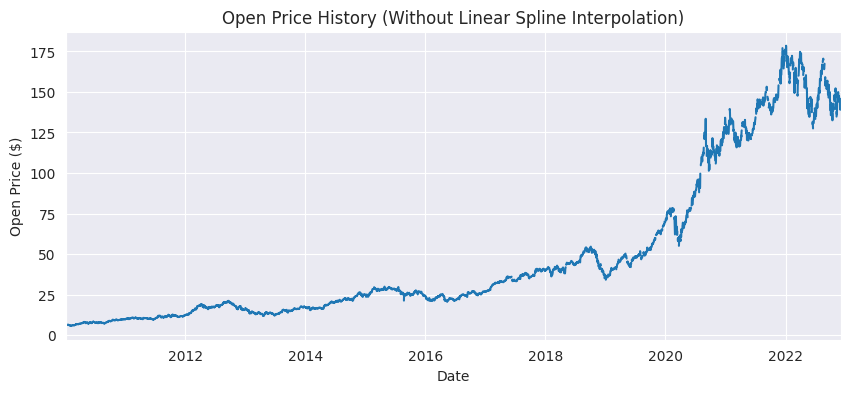

In [ ]:
plt.figure(figsize = (10, 4))
sns.set_style("darkgrid")
df2['open'].plot(kind = "line")
plt.title("Open Price History (Without Linear Spline Interpolation)")
plt.xlabel("Date")
plt.ylabel("Open Price ($)")
plt.show()

In [ ]:
df2.isna().sum()

,0
close,1463
high,1463
low,1463
open,1463
volume,1463


In [ ]:
close_series_with_gaps = df2['close']

# Linear Spline Interpolation

In [ ]:
all_idx = np.arange(len(close_series_with_gaps))

In [ ]:
valid_mask = ~close_series_with_gaps.isna()
valid_idx = all_idx[valid_mask]
valid_values = close_series_with_gaps[valid_mask]

In [ ]:
linear_spline_function = interp1d(valid_idx, valid_values, kind = "linear", fill_value = "extrapolate")

In [ ]:
interpolated_values = linear_spline_function(all_idx)

In [ ]:
clean_close_series = pd.Series(interpolated_values, index = close_series_with_gaps.index)

In [ ]:
clean_close_series.head(5)

,0
2010-01-04,6.406481
2010-01-05,6.417556
2010-01-06,6.315476
2010-01-07,6.303802
2010-01-08,6.345710


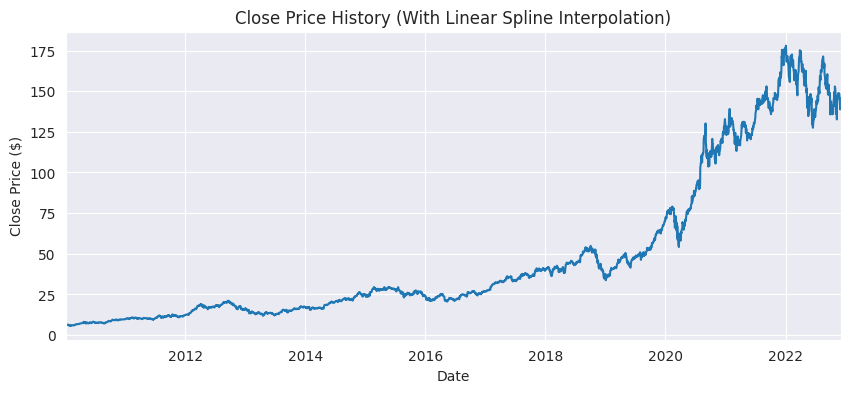

In [ ]:
plt.figure(figsize = (10, 4))
sns.set_style("darkgrid")
clean_close_series.plot(kind = "line")
plt.title("Close Price History (With Linear Spline Interpolation)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.show()

# Train-Test-Split

In [ ]:
split_idx = int(len(clean_close_series) * 0.8)
train_series = clean_close_series[:split_idx]
test_series = clean_close_series[split_idx:]

# Stationarity Test

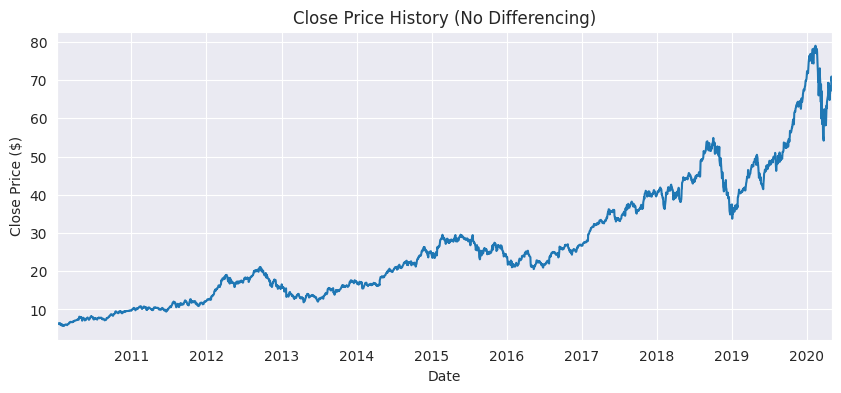

In [ ]:
plt.figure(figsize = (10, 4))
sns.set_style("darkgrid")
train_series.plot(kind = "line")
plt.title("Close Price History (No Differencing)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.show()

In [ ]:
result = adfuller(train_series)
print("ADF Statistic: %f" % result[0])
print("p-value: %f" % result[1])

ADF Statistic: 0.169382
p-value: 0.970491


In [ ]:
close_series_diff = train_series.diff().dropna()

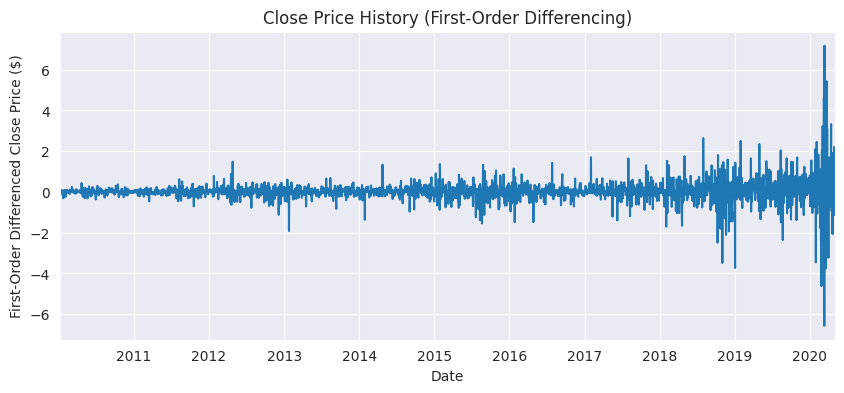

In [ ]:
plt.figure(figsize = (10, 4))
sns.set_style("darkgrid")
close_series_diff.plot(kind = "line")
plt.title("Close Price History (First-Order Differencing)")
plt.xlabel("Date")
plt.ylabel("First-Order Differenced Close Price ($)")
plt.show()

In [ ]:
result1 = adfuller(close_series_diff)
print("ADF Statistic: %f" % result1[0])
print("p-value: %f" % result1[1])

ADF Statistic: -9.818258
p-value: 0.000000


# Model Training - ARIMA

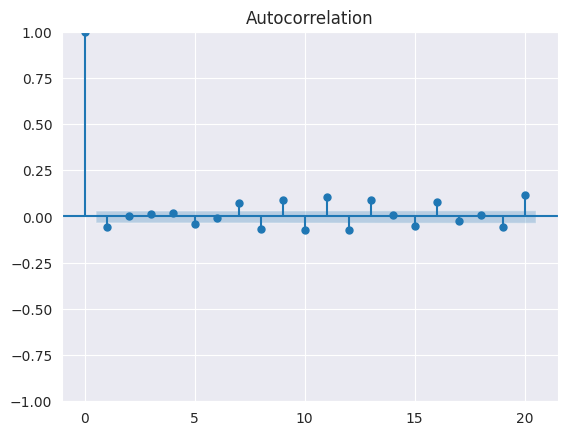

In [ ]:
plot_acf(close_series_diff, lags = 20)
plt.show()

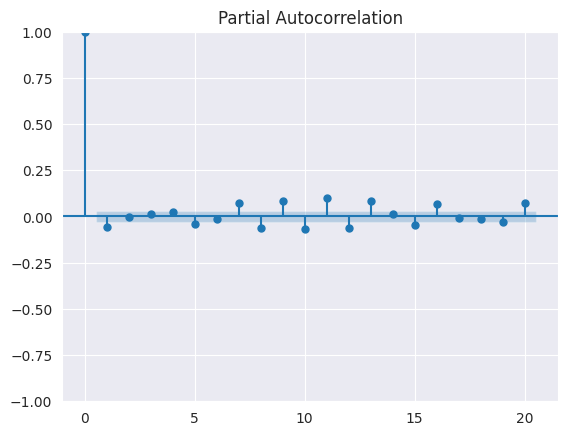

In [ ]:
plot_pacf(close_series_diff, lags = 20)
plt.show()

In [ ]:
model = ARIMA(train_series, order = (2, 1, 3))
model_fitted = model.fit()

print(model_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3772
Model:                 ARIMA(2, 1, 3)   Log Likelihood               -2470.028
Date:                Sun, 07 Jun 2026   AIC                           4952.057
Time:                        13:45:20   BIC                           4989.467
Sample:                    01-04-2010   HQIC                          4965.357
                         - 05-02-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0986      0.004     26.583      0.000       0.091       0.106
ar.L2         -0.9905      0.004   -254.477      0.000      -0.998      -0.983
ma.L1         -0.1543      0.007    -23.271      0.0

# Model Evaluation

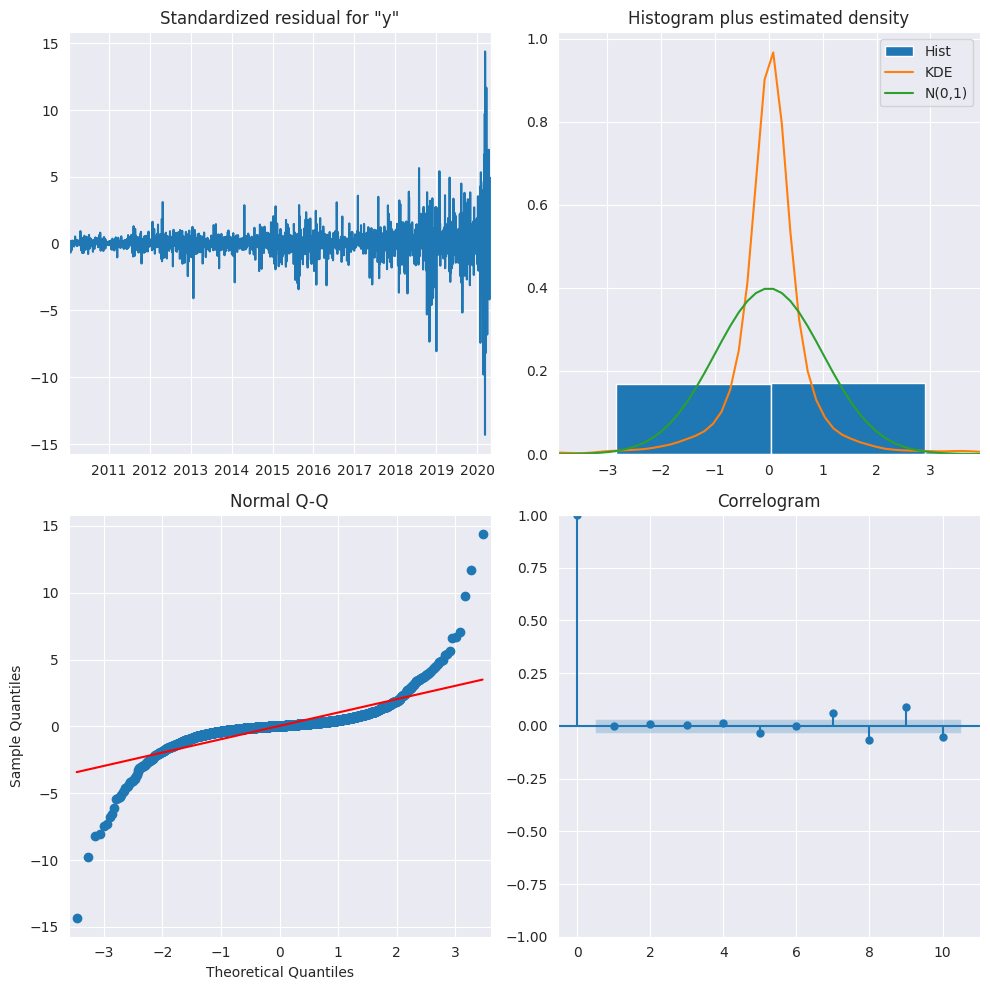

In [ ]:
model_fitted.plot_diagnostics(figsize = (10, 10))
plt.tight_layout()
plt.show()

In [ ]:
lb_results = acorr_ljungbox(model_fitted.resid,
                            lags = list(range(1, 21)),
                            return_df = True)
print(lb_results)

       lb_stat     lb_pvalue
1     0.011282  9.154092e-01
2     0.147781  9.287736e-01
3     0.235249  9.717079e-01
4     0.892118  9.256889e-01
5     4.885464  4.300178e-01
6     4.890338  5.579533e-01
7    17.800629  1.290265e-02
8    33.847498  4.329429e-05
9    61.422773  7.124741e-10
10   71.936642  1.871705e-11
11  103.259876  4.030577e-17
12  120.294703  5.398131e-20
13  149.334523  2.806484e-25
14  150.872605  4.808945e-25
15  158.720454  4.427651e-26
16  173.456185  1.718854e-28
17  174.683145  3.299858e-28
18  175.130522  8.812498e-28
19  185.773026  2.249361e-29
20  223.456810  2.436632e-36


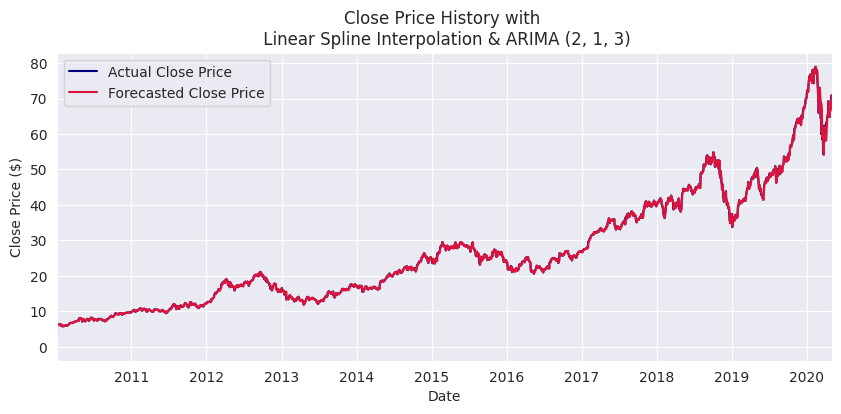

In [ ]:
plt.figure(figsize = (10, 4))
forecast_train = model_fitted.predict(train_series.index[0], train_series.index[-1])
train_series.plot(kind = "line", color = "navy", label = "Actual Close Price")
forecast_train.plot(kind = "line", color = "crimson", label = "Forecasted Close Price")
plt.title("Close Price History with \n Linear Spline Interpolation & ARIMA (2, 1, 3)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.show()

# Rolling Forecast

In [ ]:
history = [x for x in train_series]
predictions = list()

model_f = ARIMA(history, order = (2, 1, 3))
model_fitted_f = model_f.fit()

for i in range(len(test_series)):
  obs = test_series[i]
  model_fitted_f = model_fitted_f.append([obs], refit = False)
  output = model_fitted_f.forecast()
  yhat = output[0]
  predictions.append(yhat)
  history.append(obs)

  print("Progress: {}/{} | Predicted: {:.2f}, Actual: {:.2f}".format(i,len(test_series), yhat, obs))


Progress: 0/944 | Predicted: 70.34, Actual: 70.44
Progress: 1/944 | Predicted: 70.84, Actual: 70.77
Progress: 2/944 | Predicted: 71.87, Actual: 71.83
Progress: 3/944 | Predicted: 72.45, Actual: 72.57
Progress: 4/944 | Predicted: 73.19, Actual: 73.32
Progress: 5/944 | Predicted: 75.05, Actual: 75.07
Progress: 6/944 | Predicted: 75.54, Actual: 75.46
Progress: 7/944 | Predicted: 75.78, Actual: 75.86
Progress: 8/944 | Predicted: 76.12, Actual: 76.25
Progress: 9/944 | Predicted: 75.47, Actual: 75.38
Progress: 10/944 | Predicted: 74.64, Actual: 74.47
Progress: 11/944 | Predicted: 74.87, Actual: 74.93
Progress: 12/944 | Predicted: 74.38, Actual: 74.48
Progress: 13/944 | Predicted: 75.06, Actual: 75.07
Progress: 14/944 | Predicted: 75.74, Actual: 75.65
Progress: 15/944 | Predicted: 76.20, Actual: 76.24
Progress: 16/944 | Predicted: 75.70, Actual: 75.80
Progress: 17/944 | Predicted: 77.19, Actual: 77.27
Progress: 18/944 | Predicted: 76.83, Actual: 76.70
Progress: 19/944 | Predicted: 77.19, Actu

In [ ]:
print("MAE: {:.4f}".format(mean_absolute_error(test_series, predictions)))
print("RMSE: {:.4f}".format(np.sqrt(mean_squared_error(test_series, predictions))))
print("R2: {:.4f}".format(r2_score(test_series, predictions)))

MAE: 0.1063
RMSE: 0.1411
R2: 1.0000


In [ ]:
predictions_df = pd.Series(predictions, index = test_series.index)

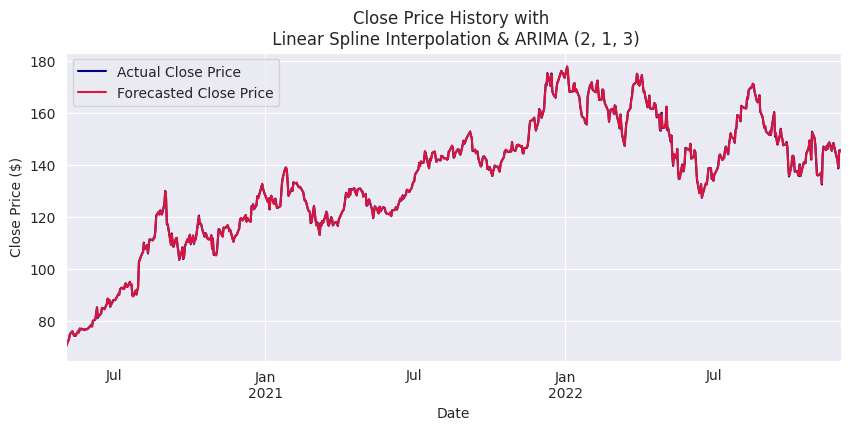

In [ ]:
plt.figure(figsize = (10, 4))
test_series.plot(kind = "line", color = "navy", label = "Actual Close Price")
predictions_df.plot(kind = "line", color = "crimson", label = "Forecasted Close Price")
plt.title("Close Price History with \n Linear Spline Interpolation & ARIMA (2, 1, 3)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.show()